In [3]:
from google.colab import files
from zipfile import ZipFile

# Unzip it
import zipfile
import io

with zipfile.ZipFile("/content/data.zip", 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')


In [4]:
! pip install torch>=1.10.0 torchvision matplotlib seaborn




In [9]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import cv2

In [10]:
# ========================
# CONFIG
# ========================
DATA_DIR = "/content/dataset/data"
TRAIN_DIR = os.path.join(DATA_DIR, "Training")
VAL_DIR   = os.path.join(DATA_DIR, "Validation")
TEST_DIR  = os.path.join(DATA_DIR, "Testing")

BATCH_SIZE = 32
NUM_EPOCHS = 60
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
# ========================
# TRANSFORMS
# ========================
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(0, translate=(0.15, 0.15)),
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])


In [12]:

# ========================
# DATASETS & LOADERS
# ========================
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_DIR, transform=val_test_transform)
test_dataset  = datasets.ImageFolder(TEST_DIR, transform=val_test_transform)

num_classes = len(train_dataset.classes)

In [13]:
# Handle imbalance
class_counts = torch.bincount(torch.tensor(train_dataset.targets))
class_weights = 1. / class_counts.float()
sample_weights = [class_weights[t] for t in train_dataset.targets]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


In [14]:

# ========================
# MODEL: Deep Custom CNN
# ========================
class DeepTeethCNN(nn.Module):
    def __init__(self, num_classes):
        super(DeepTeethCNN, self).__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, 3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            conv_block(3, 64),
            conv_block(64, 128),
            conv_block(128, 256),
            conv_block(256, 512),
            conv_block(512, 1024),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = DeepTeethCNN(num_classes).to(DEVICE)

In [15]:
# ========================
# LOSS, OPTIMIZER, SCHEDULER
# ========================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [16]:
# ========================
# EVALUATION
# ========================
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total


In [17]:
# ========================
# TRAINING LOOP
# ========================
def train_model(model, train_loader, val_loader, epochs):
    best_acc = 0
    train_losses, val_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for images, labels in loop:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            loop.set_postfix(loss=loss.item(), acc=100.*correct/total)

        avg_loss = running_loss / len(train_loader.dataset)
        val_acc = evaluate(model, val_loader)
        train_losses.append(avg_loss)
        val_accuracies.append(val_acc)

        scheduler.step()
        print(f"Epoch {epoch+1}: Train Loss={avg_loss:.4f}, Val Acc={val_acc:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_teeth_cnn.pth")

    # Plot curves
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.plot(train_losses); plt.title("Train Loss")
    plt.subplot(1,2,2); plt.plot(val_accuracies); plt.title("Val Accuracy")
    plt.show()

    print(f"Best Validation Accuracy: {best_acc:.2f}%")

Epoch 1: Train Loss=2.0143, Val Acc=25.19%


Epoch 2: Train Loss=1.9109, Val Acc=28.40%


Epoch 3: Train Loss=1.8396, Val Acc=31.52%


Epoch 4: Train Loss=1.8075, Val Acc=14.79%


Epoch 5: Train Loss=1.7804, Val Acc=32.68%


...

Epoch 56: Train Loss=0.6701, Val Acc=95.04%


Epoch 57: Train Loss=0.6654, Val Acc=95.04%


Epoch 58: Train Loss=0.6676, Val Acc=95.43%


Epoch 59: Train Loss=0.6674, Val Acc=95.23%


Epoch 60: Train Loss=0.6710, Val Acc=94.55%


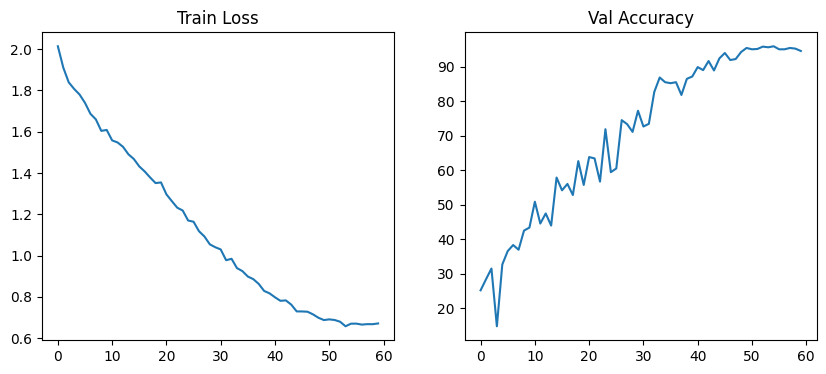

Best Validation Accuracy: 95.91%
✅ Final Test Accuracy: 96.30%


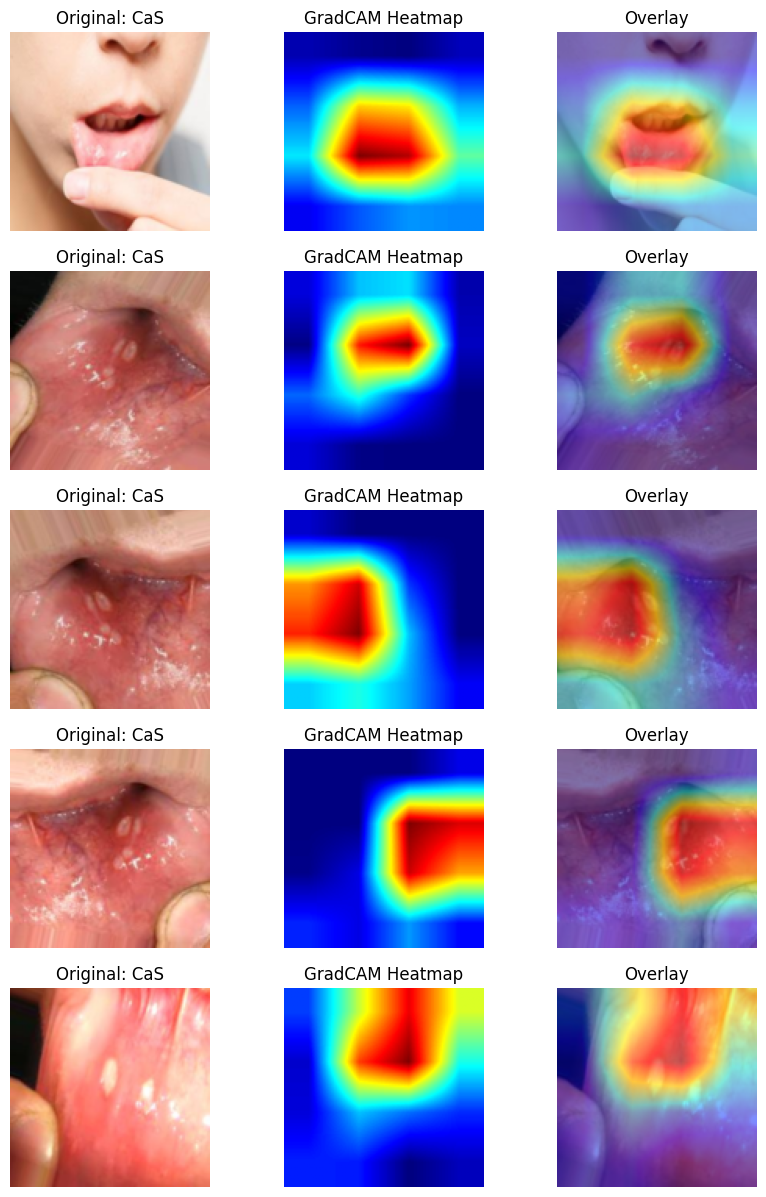

In [18]:

# ========================
# GRADCAM UTILS
# ========================
def generate_gradcam(model, image, target_layer, target_class=None):
    gradients = []
    activations = []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0].detach())

    def forward_hook(module, input, output):
        activations.append(output.detach())

    handle_fw = target_layer.register_forward_hook(forward_hook)
    handle_bw = target_layer.register_backward_hook(backward_hook)

    model.eval()
    image = image.unsqueeze(0).to(DEVICE)
    output = model(image)
    if target_class is None:
        target_class = output.argmax(dim=1).item()

    loss = output[0, target_class]
    model.zero_grad()
    loss.backward()

    grads = gradients[0].mean(dim=[2, 3], keepdim=True)
    act = activations[0]
    cam = (act * grads).sum(dim=1).squeeze().cpu().numpy()
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (128, 128))
    cam = cam - cam.min()
    cam = cam / cam.max()

    handle_fw.remove()
    handle_bw.remove()
    return cam

def visualize_gradcam(model, dataset, target_layer, classes, num_images=5):
    fig, axs = plt.subplots(num_images, 3, figsize=(10, num_images*3))
    for i in range(num_images):
        img, label = dataset[i]
        cam = generate_gradcam(model, img, target_layer, target_class=label)

        img_np = img.permute(1,2,0).numpy()
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

        heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        overlay = 0.5*img_np + 0.5*heatmap

        axs[i,0].imshow(img_np); axs[i,0].set_title(f"Original: {classes[label]}")
        axs[i,1].imshow(heatmap); axs[i,1].set_title("GradCAM Heatmap")
        axs[i,2].imshow(overlay); axs[i,2].set_title("Overlay")
        for j in range(3): axs[i,j].axis("off")
    plt.show()

# ========================
# MAIN
# ========================
train_model(model, train_loader, val_loader, NUM_EPOCHS)

# Load best & test
model.load_state_dict(torch.load("best_teeth_cnn.pth"))
test_acc = evaluate(model, test_loader)
print(f"✅ Final Test Accuracy: {test_acc:.2f}%")

# ========================
# VISUALIZATION
# ========================
target_layer = model.features[-1]  # last conv block
visualize_gradcam(model, test_dataset, target_layer, train_dataset.classes, num_images=5)
